In [1]:
# ============================================
# Notebook 07
# Expense Tracker Dashboard
# ============================================

import pandas as pd
import matplotlib.pyplot as plt
import os

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (10,6)

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [2]:
project_folder = "Executive_Assistant_Business_Dashboard"

data_folder = os.path.join(project_folder, "data")
reports_folder = os.path.join(project_folder, "reports")
charts_folder = os.path.join(project_folder, "charts")

os.makedirs(reports_folder, exist_ok=True)
os.makedirs(charts_folder, exist_ok=True)

In [3]:
expense_file = os.path.join(data_folder, "expenses.xlsx")

expense_df = pd.read_excel(expense_file)

expense_df.head()

,Expense_ID,Expense_Date,Category,Department,Vendor,Amount,Payment_Mode,Approval_Status,Approved_By
0,EXP0001,2025-07-24 20:36:45.783,Training,IT,Pingle-Singhal,4968.36,Cash,Rejected,Harish Kothari
1,EXP0002,2026-02-19 20:36:45.783,Utilities,HR,Bhakta-Grewal,41030.60,Credit Card,Rejected,Ekalinga Mander
2,EXP0003,2026-02-03 20:36:45.783,Food,Sales,"Kohli, Gour and Garde",8934.48,Credit Card,Pending,Gaurika Vala
3,EXP0004,2025-12-19 20:36:45.783,Travel,IT,"Mutti, Sur and Rau",9845.03,Credit Card,Pending,Anthony Kant
4,EXP0005,2026-02-13 20:36:45.783,Software,Marketing,Kohli and Sons,42963.45,Bank Transfer,Pending,Yutika Verma


In [4]:
expense_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Expense_ID       500 non-null    object        
 1   Expense_Date     500 non-null    datetime64[ns]
 2   Category         500 non-null    object        
 3   Department       500 non-null    object        
 4   Vendor           500 non-null    object        
 5   Amount           500 non-null    float64       
 6   Payment_Mode     500 non-null    object        
 7   Approval_Status  500 non-null    object        
 8   Approved_By      500 non-null    object        
dtypes: datetime64[ns](1), float64(1), object(7)
memory usage: 35.3+ KB


In [5]:
expense_df.isnull().sum()

Expense_ID         0
Expense_Date       0
Category           0
Department         0
Vendor             0
Amount             0
Payment_Mode       0
Approval_Status    0
Approved_By        0
dtype: int64

In [6]:
expense_df["Expense_Date"] = pd.to_datetime(expense_df["Expense_Date"])

expense_df["Year"] = expense_df["Expense_Date"].dt.year
expense_df["Month"] = expense_df["Expense_Date"].dt.month_name()

In [7]:
total_expense = round(expense_df["Amount"].sum(),2)

average_expense = round(expense_df["Amount"].mean(),2)

highest_expense = round(expense_df["Amount"].max(),2)

lowest_expense = round(expense_df["Amount"].min(),2)

approved = (expense_df["Approval_Status"]=="Approved").sum()

pending = (expense_df["Approval_Status"]=="Pending").sum()

rejected = (expense_df["Approval_Status"]=="Rejected").sum()

In [8]:
print("="*60)

print("EXPENSE DASHBOARD")

print("="*60)

print(f"Total Expense        : ₹{total_expense:,.2f}")

print(f"Average Expense      : ₹{average_expense:,.2f}")

print(f"Highest Expense      : ₹{highest_expense:,.2f}")

print(f"Lowest Expense       : ₹{lowest_expense:,.2f}")

print(f"Approved Expenses    : {approved}")

print(f"Pending Approval     : {pending}")

print(f"Rejected Expenses    : {rejected}")

EXPENSE DASHBOARD
Total Expense        : ₹13,090,267.25
Average Expense      : ₹26,180.53
Highest Expense      : ₹49,997.56
Lowest Expense       : ₹912.84
Approved Expenses    : 168
Pending Approval     : 169
Rejected Expenses    : 163


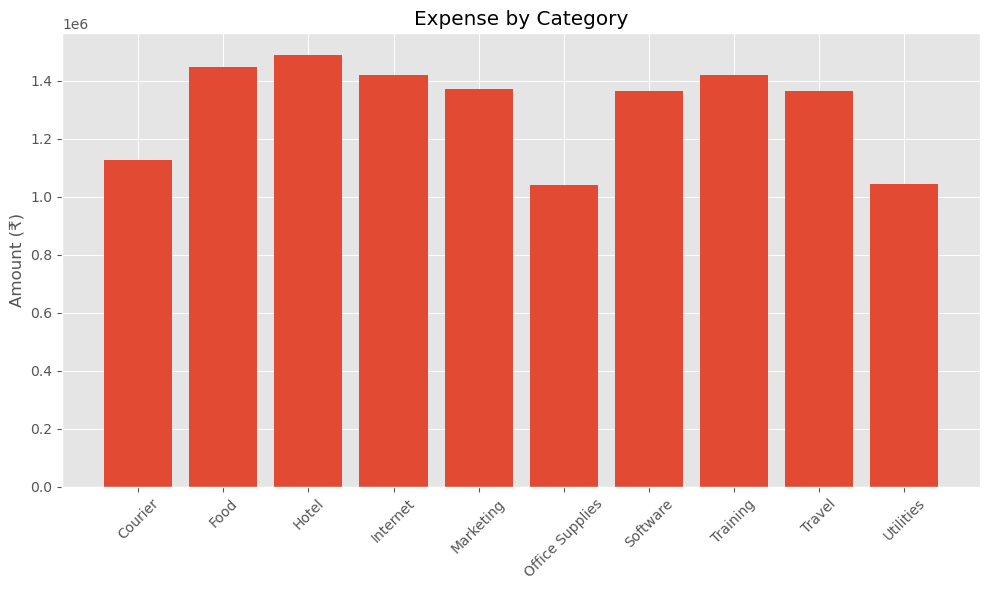

In [9]:
category = expense_df.groupby("Category")["Amount"].sum()

plt.figure(figsize=(10,6))

plt.bar(category.index, category.values)

plt.xticks(rotation=45)

plt.title("Expense by Category")

plt.ylabel("Amount (₹)")

plt.tight_layout()

plt.savefig(os.path.join(charts_folder,"Expense_Category.png"))

plt.show()

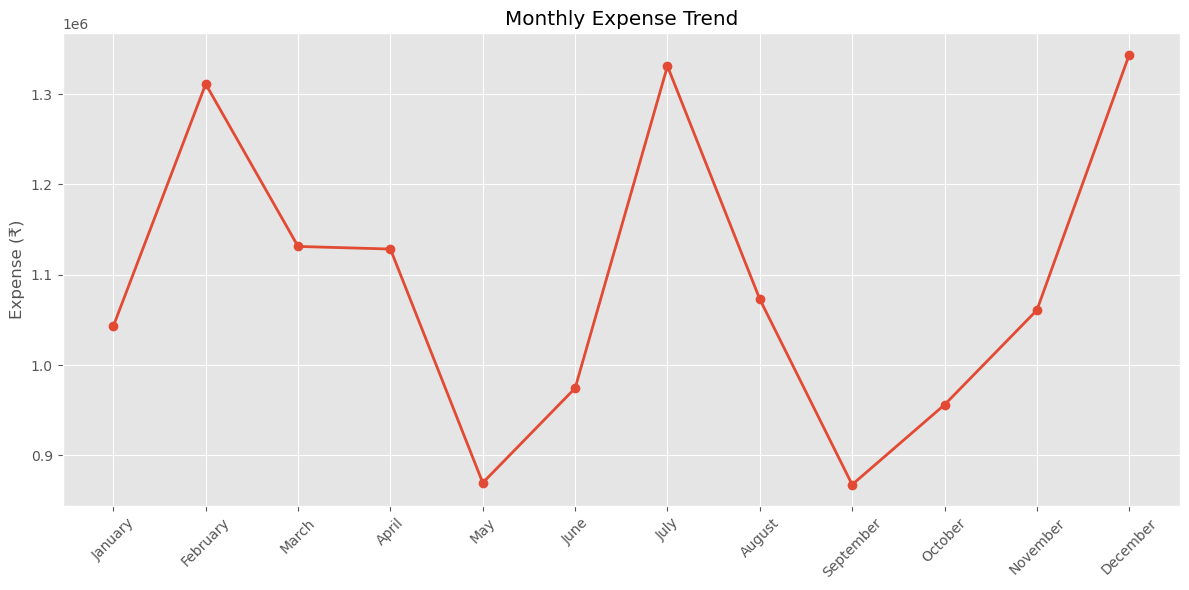

In [10]:
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

monthly = expense_df.groupby("Month")["Amount"].sum()
monthly = monthly.reindex(month_order)

plt.figure(figsize=(12,6))

plt.plot(monthly.index,
         monthly.values,
         marker="o",
         linewidth=2)

plt.xticks(rotation=45)

plt.title("Monthly Expense Trend")

plt.ylabel("Expense (₹)")

plt.tight_layout()

plt.savefig(os.path.join(charts_folder,"Monthly_Expense_Trend.png"))

plt.show()

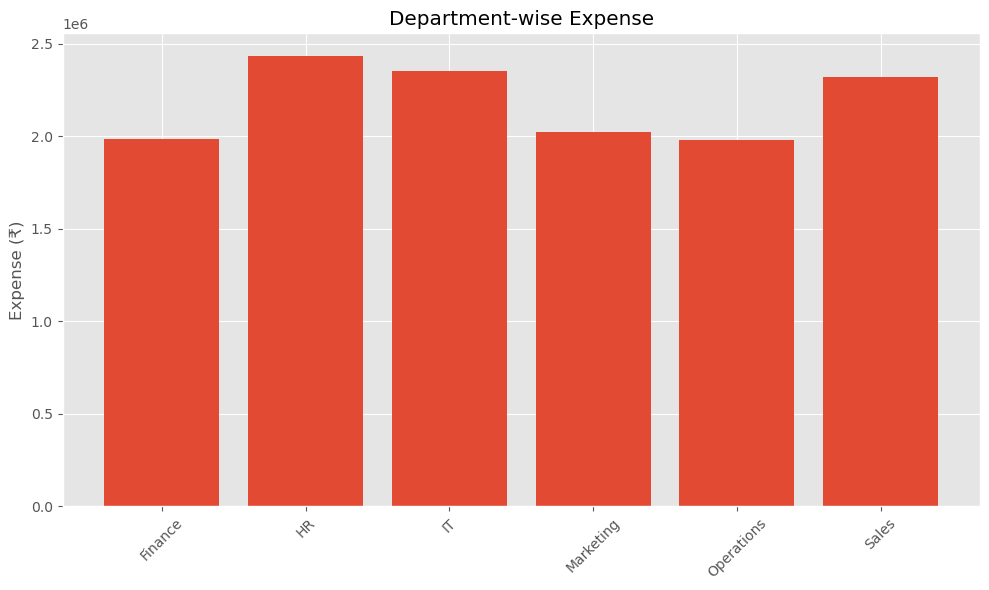

In [11]:
department = expense_df.groupby("Department")["Amount"].sum()

plt.figure(figsize=(10,6))

plt.bar(department.index,
        department.values)

plt.xticks(rotation=45)

plt.title("Department-wise Expense")

plt.ylabel("Expense (₹)")

plt.tight_layout()

plt.savefig(os.path.join(charts_folder,"Department_Expense.png"))

plt.show()

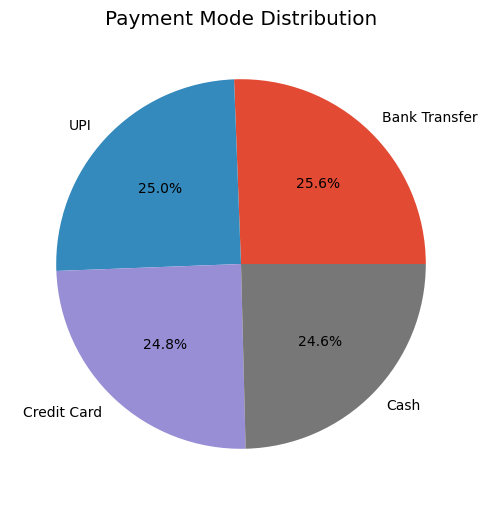

In [12]:
payment = expense_df["Payment_Mode"].value_counts()

plt.figure(figsize=(8,6))

plt.pie(payment.values,
        labels=payment.index,
        autopct="%1.1f%%")

plt.title("Payment Mode Distribution")

plt.savefig(os.path.join(charts_folder,"Payment_Mode.png"))

plt.show()

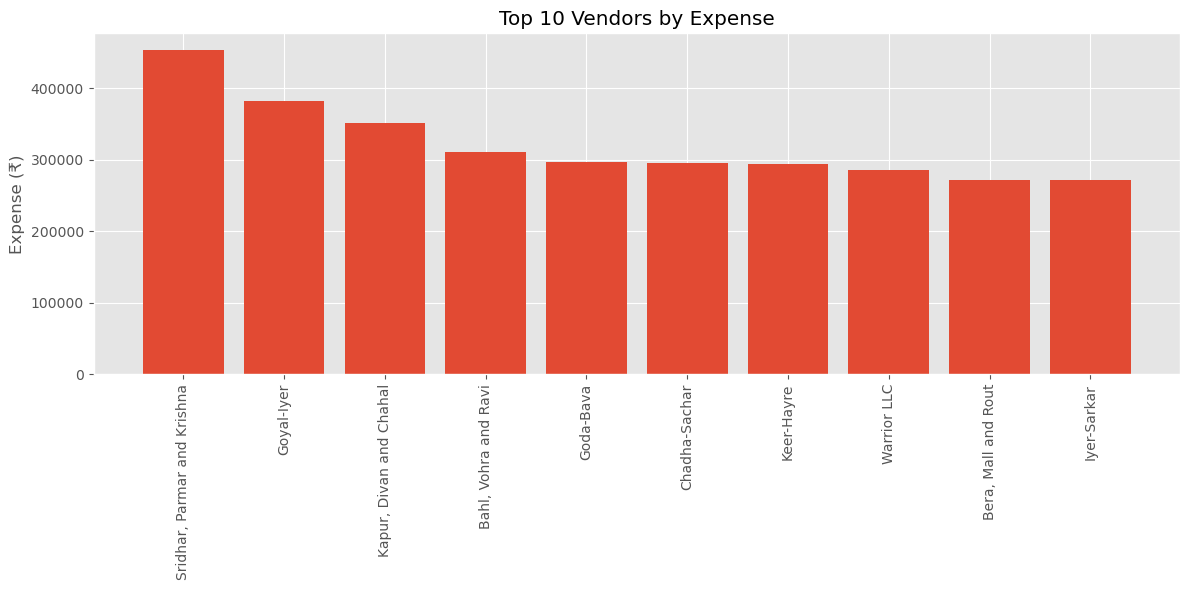

In [13]:
vendor = expense_df.groupby("Vendor")["Amount"].sum()

vendor = vendor.sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))

plt.bar(vendor.index,
        vendor.values)

plt.xticks(rotation=90)

plt.title("Top 10 Vendors by Expense")

plt.ylabel("Expense (₹)")

plt.tight_layout()

plt.savefig(os.path.join(charts_folder,"Top_Vendor_Expense.png"))

plt.show()

In [14]:
summary = pd.DataFrame({

    "Metric":[
        "Total Expense",
        "Average Expense",
        "Highest Expense",
        "Lowest Expense",
        "Approved",
        "Pending",
        "Rejected"
    ],

    "Value":[
        total_expense,
        average_expense,
        highest_expense,
        lowest_expense,
        approved,
        pending,
        rejected
    ]

})

summary.to_excel(

    os.path.join(

        reports_folder,

        "Expense_Summary.xlsx"

    ),

    index=False

)

print("Expense Summary Saved Successfully")

Expense Summary Saved Successfully


In [15]:
expense_df.sort_values(
    "Amount",
    ascending=False
).head(10)

,Expense_ID,Expense_Date,Category,Department,Vendor,Amount,Payment_Mode,Approval_Status,Approved_By,Year,Month
113,EXP0114,2026-06-14 20:36:45.784,Software,Finance,"Sekhon, Gulati and Parekh",49997.56,Credit Card,Pending,Victor Sinha,2026,June
217,EXP0218,2026-02-20 20:36:45.785,Training,Sales,Nadig Group,49963.72,Bank Transfer,Rejected,Ishaan Prakash,2026,February
319,EXP0320,2025-12-12 20:36:45.790,Office Supplies,Sales,Chandran-Parekh,49945.70,UPI,Pending,Jai Dua,2025,December
393,EXP0394,2025-07-24 20:36:45.793,Food,HR,"Bora, Prasad and Ben",49854.54,UPI,Pending,Xavier Mani,2025,July
340,EXP0341,2026-04-29 20:36:45.791,Software,HR,Choudhry-Sunder,49841.96,UPI,Rejected,Anthony Kant,2026,April
194,EXP0195,2026-01-25 20:36:45.785,Training,Sales,Mangat and Sons,49824.92,Credit Card,Pending,Ekavir Uppal,2026,January
172,EXP0173,2026-04-29 20:36:45.785,Internet,Sales,Mangat and Sons,49815.04,UPI,Pending,Jai Dua,2026,April
185,EXP0186,2026-05-17 20:36:45.785,Marketing,Marketing,Goyal-Iyer,49520.78,UPI,Rejected,Jai Dua,2026,May
49,EXP0050,2025-09-09 20:36:45.784,Utilities,Operations,Goda-Bava,49463.55,Credit Card,Approved,Wahab Dugar,2025,September
444,EXP0445,2026-03-31 20:36:45.794,Marketing,Marketing,Bhatnagar Inc,49217.74,UPI,Rejected,Omya Bera,2026,March


In [16]:
print("="*60)

print("EXPENSE DASHBOARD COMPLETED")

print("="*60)

print(f"Charts Saved  : {charts_folder}")

print(f"Reports Saved : {reports_folder}")

print("="*60)

EXPENSE DASHBOARD COMPLETED
Charts Saved  : Executive_Assistant_Business_Dashboard\charts
Reports Saved : Executive_Assistant_Business_Dashboard\reports
